# NLI Fine-Tuning Assignment

This notebook runs all 5 tasks:
- **Task 1:** Baseline Full Fine-Tuning
- **Task 2:** Hyperparameter Sensitivity Study
- **Task 3:** Parameter-Efficient Fine-Tuning (PEFT)
- **Task 4:** Cross-Dataset Generalisation
- **Task 5:** Data Efficiency Analysis

**Hardware:** GPU required (Colab T4 is sufficient)  
**Runtime:** ~30–60 minutes on a T4 GPU with default settings

## 0. Setup

### 0.1 Install Dependencies

In [2]:
!pip install -q transformers datasets torch scikit-learn matplotlib seaborn peft accelerate

### 0.2 Imports and Configuration

In [14]:
import os
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════
#  SPEED CONFIGURATION — Adjust these to trade speed vs thoroughness
# ═══════════════════════════════════════════════════════════
MODEL_NAME     = "distilbert-base-uncased"
MAX_LENGTH     = 128
SEED           = 42

# Fraction of SNLI training data to use (1.0 = full dataset ~550K)
# Use 0.1 for fast runs (~55K), 0.25 for moderate (~137K), 1.0 for full
TRAIN_FRACTION = 0.1

# Max eval/test examples (None = use all)
MAX_EVAL_EXAMPLES = 5000
MAX_TEST_EXAMPLES = 5000

# Training defaults
DEFAULT_EPOCHS     = 3
DEFAULT_LR         = 2e-5
DEFAULT_BATCH_SIZE = 32

# Enable mixed precision (much faster on GPU, set False for CPU)
USE_FP16 = torch.cuda.is_available()

# ═══════════════════════════════════════════════════════════

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Train fraction: {TRAIN_FRACTION:.0%}")
print(f"FP16: {USE_FP16}")

LABEL_NAMES = ["entailment", "neutral", "contradiction"]

Device: cuda
Train fraction: 10%
FP16: True


### 0.3 Helper Functions

In [15]:
def set_seed(seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_fresh_model(model_name=MODEL_NAME, num_labels=3):
    """Always load a fresh model from pre-trained weights."""
    set_seed()
    return AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels
    )


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}


def get_predictions(trainer, dataset):
    output = trainer.predict(dataset)
    preds = np.argmax(output.predictions, axis=-1)
    return preds, output.label_ids


def make_training_args(output_dir, lr=DEFAULT_LR, batch_size=DEFAULT_BATCH_SIZE,
                       epochs=DEFAULT_EPOCHS, **kwargs):
    """Create TrainingArguments with speed optimizations baked in."""
    return TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=128,
        num_train_epochs=epochs,
        warmup_ratio=0.06,
        weight_decay=0.01,
        logging_steps=100,
        fp16=USE_FP16,
        dataloader_num_workers=2,
        report_to="none",
        seed=SEED,
        **kwargs,
    )


def cleanup():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

### 0.4 Load, Subsample, and Tokenize SNLI

In [16]:
# Load and filter
dataset = load_dataset("snli")
dataset = dataset.filter(lambda x: x["label"] != -1)
print(f"Full dataset — Train: {len(dataset['train']):,}  "
      f"Val: {len(dataset['validation']):,}  Test: {len(dataset['test']):,}")

# Subsample for speed
set_seed()
train_n = int(len(dataset["train"]) * TRAIN_FRACTION)
train_subset = dataset["train"].shuffle(seed=SEED).select(range(train_n))

val_data = dataset["validation"]
if MAX_EVAL_EXAMPLES and len(val_data) > MAX_EVAL_EXAMPLES:
    val_data = val_data.shuffle(seed=SEED).select(range(MAX_EVAL_EXAMPLES))

test_data = dataset["test"]
if MAX_TEST_EXAMPLES and len(test_data) > MAX_TEST_EXAMPLES:
    test_data = test_data.shuffle(seed=SEED).select(range(MAX_TEST_EXAMPLES))

print(f"\nUsing — Train: {len(train_subset):,}  Val: {len(val_data):,}  Test: {len(test_data):,}")

Full dataset — Train: 549,367  Val: 9,842  Test: 9,824

Using — Train: 54,936  Val: 5,000  Test: 5,000


In [17]:
# Tokenize
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch["premise"], batch["hypothesis"],
        truncation=True, max_length=MAX_LENGTH, padding="max_length",
    )

train_tok = train_subset.map(tokenize_fn, batched=True, num_proc=2)
val_tok   = val_data.map(tokenize_fn, batched=True, num_proc=2)
test_tok  = test_data.map(tokenize_fn, batched=True, num_proc=2)
print("Tokenization complete.")

Tokenization complete.


---
## Task 1: Baseline Full Fine-Tuning

**Goal:** Fine-tune a pre-trained model on SNLI to establish a baseline.

### 1(a) Perform Task

In [ ]:
# Load fresh model
set_seed()
model = get_fresh_model()

# Training arguments
args = TrainingArguments(
    output_dir="./results/task1",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    warmup_ratio=0.06,
    weight_decay=0.01,
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

print("Training baseline model...")
start = time.time()
trainer.train()
train_time = time.time() - start
print(f"\nTraining completed in {train_time / 60:.1f} minutes")

# Save model for later tasks
trainer.save_model(str(MODEL_DIR / "task1_baseline"))

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training baseline model...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.547983,0.480029,0.809400
2,0.423633,0.445399,0.834600
3,0.343238,0.466033,0.833400


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training completed in 32.0 minutes


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### 1(b) Analysis and Plots

Test Accuracy: 0.8280



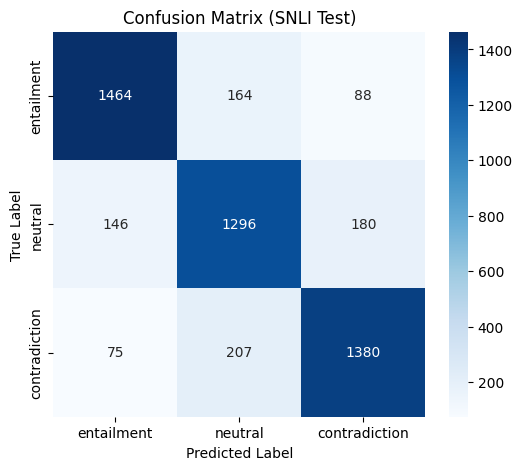

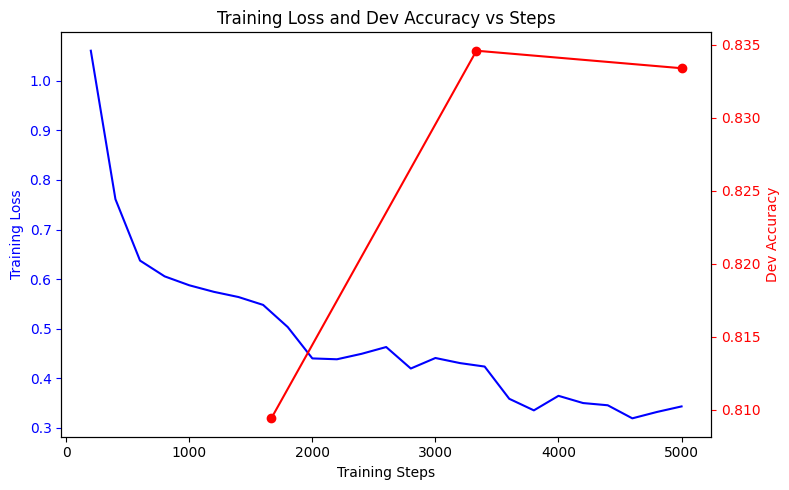

Classification Report:
               precision    recall  f1-score   support

   entailment       0.87      0.85      0.86      1716
      neutral       0.78      0.80      0.79      1622
contradiction       0.84      0.83      0.83      1662

     accuracy                           0.83      5000
    macro avg       0.83      0.83      0.83      5000
 weighted avg       0.83      0.83      0.83      5000



In [ ]:
preds, labels = get_predictions(trainer, test_tok)
test_acc = accuracy_score(labels, preds)
print(f"Test Accuracy: {test_acc:.4f}\n")

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (SNLI Test)")
plt.show()

log_history = trainer.state.log_history
train_loss = [log["loss"] for log in log_history if "loss" in log]
train_steps = [log["step"] for log in log_history if "loss" in log]

eval_acc = [log["eval_accuracy"] for log in log_history if "eval_accuracy" in log]
eval_epochs = [log["epoch"] for log in log_history if "eval_accuracy" in log]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(train_steps, train_loss, 'b-', label="Training Loss")
ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Training Loss", color='b')
ax1.tick_params('y', colors='b')

ax2 = ax1.twinx()
ax2.plot([step * (train_steps[-1]/eval_epochs[-1]) for step in eval_epochs], eval_acc, 'r-o', label="Dev Accuracy")
ax2.set_ylabel("Dev Accuracy", color='r')
ax2.tick_params('y', colors='r')

plt.title("Training Loss and Dev Accuracy vs Steps")
fig.tight_layout()
plt.show()

report = classification_report(labels, preds, target_names=LABEL_NAMES)
print("Classification Report:")
print(report)

### 1(c) Comparative Study

### 1(d) Possible Reasons Behind Observations

---
## Task 2: Hyperparameter Sensitivity Study

**Goal:** Understand how key hyperparameters affect fine-tuning performance.

### 2(a) Perform Task

In [ ]:
lrs = [1e-5, 2e-5, 5e-5, 1e-4]
batch_sizes = [16, 32, 64]
epochs = [1, 2, 3, 5]

results_lr = []
results_bs = []
results_ep = []

for lr in lrs:
    set_seed()
    model = get_fresh_model()
    args = make_training_args(f"./results/t2_lr_{lr}", lr=lr)
    trainer = Trainer(model=model, args=args, train_dataset=train_tok, eval_dataset=val_tok, compute_metrics=compute_metrics)
    trainer.train()
    metrics = trainer.evaluate()
    results_lr.append({"lr": lr, "acc": metrics["eval_accuracy"]})
    cleanup()

for bs in batch_sizes:
    set_seed()
    model = get_fresh_model()
    args = make_training_args(f"./results/t2_bs_{bs}", batch_size=bs)
    trainer = Trainer(model=model, args=args, train_dataset=train_tok, eval_dataset=val_tok, compute_metrics=compute_metrics)
    trainer.train()
    metrics = trainer.evaluate()
    results_bs.append({"bs": bs, "acc": metrics["eval_accuracy"]})
    cleanup()

for ep in epochs:
    set_seed()
    model = get_fresh_model()
    args = make_training_args(f"./results/t2_ep_{ep}", epochs=ep)
    trainer = Trainer(model=model, args=args, train_dataset=train_tok, eval_dataset=val_tok, compute_metrics=compute_metrics)
    trainer.train()
    metrics = trainer.evaluate()
    results_ep.append({"ep": ep, "acc": metrics["eval_accuracy"]})
    cleanup()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.574494,0.513040,0.799600
2,0.495072,0.475182,0.817000
3,0.447737,0.473766,0.820000


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.537056,0.482484,0.810200
2,0.437645,0.449632,0.828800
3,0.348080,0.470799,0.833200


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.543151,0.485952,0.805200
2,0.444300,0.446120,0.829600
3,0.344739,0.483730,0.829400
4,0.249305,0.528857,0.834400
5,0.208536,0.567340,0.832000


### 2(b) Analysis and Plots

Learning Rate Results:
     lr    acc
0.00001 0.8200
0.00002 0.8332
0.00005 0.8344
0.00010 0.8336

Batch Size Results:
 bs    acc
 16 0.8390
 32 0.8332
 64 0.8292

Epochs Results:
 ep    acc
  1 0.8144
  2 0.8326
  3 0.8332
  5 0.8320


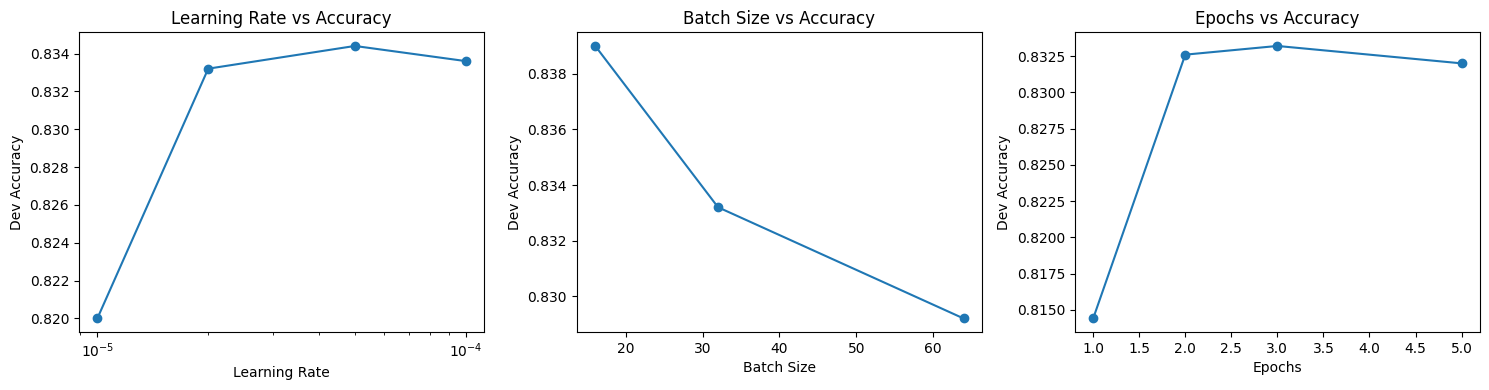

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_lr = pd.DataFrame(results_lr)
df_bs = pd.DataFrame(results_bs)
df_ep = pd.DataFrame(results_ep)

print("Learning Rate Results:")
print(df_lr.to_string(index=False))
print("\nBatch Size Results:")
print(df_bs.to_string(index=False))
print("\nEpochs Results:")
print(df_ep.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_lr['lr'], df_lr['acc'], marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Dev Accuracy')
axes[0].set_title('Learning Rate vs Accuracy')

axes[1].plot(df_bs['bs'], df_bs['acc'], marker='o')
axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Dev Accuracy')
axes[1].set_title('Batch Size vs Accuracy')

axes[2].plot(df_ep['ep'], df_ep['acc'], marker='o')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Dev Accuracy')
axes[2].set_title('Epochs vs Accuracy')

plt.tight_layout()
plt.show()

### 2(c) Comparative Study

### 2(d) Possible Reasons Behind Observations

---
## Task 3: Parameter-Efficient Fine-Tuning (PEFT)

**Goal:** Compare full fine-tuning against parameter-efficient methods.

### 3(a) Perform Task

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

peft_results = []

# Full fine-tuning
print("Full fine-tuning...")
set_seed()
model = get_fresh_model()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
t = Trainer(model=model, args=make_training_args("./results/t3_full"),
            train_dataset=train_tok, eval_dataset=val_tok,
            compute_metrics=compute_metrics)
start = time.time()
t.train()
elapsed = time.time() - start
acc = t.evaluate()["eval_accuracy"]
peft_results.append({"method": "Full FT", "params": total_params, "pct": 100.0,
                      "acc": acc, "time": elapsed/60})
print(f"  {total_params:,} params | acc={acc:.4f} | {elapsed/60:.1f}m")
del model, t; cleanup()

Full fine-tuning...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.537056,0.482484,0.810200
2,0.437645,0.449632,0.828800
3,0.348080,0.470799,0.833200


  66,955,779 params | acc=0.8332 | 9.3m


In [ ]:
# Detect LoRA target modules
probe = get_fresh_model()
mnames = [n for n, _ in probe.named_modules()]
target_modules = ["q_lin", "v_lin"] if any("q_lin" in n for n in mnames) else ["query", "value"]
del probe
print(f"LoRA targets: {target_modules}")

# LoRA sweeps
for rank in [4, 8, 16]:
    print(f"\nLoRA r={rank}...")
    set_seed()
    model = get_fresh_model()
    model = get_peft_model(model, LoraConfig(
        task_type=TaskType.SEQ_CLS, r=rank, lora_alpha=16,
        lora_dropout=0.1, target_modules=target_modules))
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    all_p = sum(p.numel() for p in model.parameters())
    pct = 100.0 * trainable / all_p
    t = Trainer(model=model, args=make_training_args(f"./results/t3_lora_r{rank}"),
                train_dataset=train_tok, eval_dataset=val_tok,
                compute_metrics=compute_metrics)
    start = time.time()
    t.train()
    elapsed = time.time() - start
    acc = t.evaluate()["eval_accuracy"]
    peft_results.append({"method": f"LoRA r={rank}", "params": trainable,
                          "pct": pct, "acc": acc, "time": elapsed/60})
    print(f"  {trainable:,} params ({pct:.2f}%) | acc={acc:.4f} | {elapsed/60:.1f}m")
    del model, t; cleanup()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LoRA targets: ['q_lin', 'v_lin']

LoRA r=4...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

  740,355 params (1.09%) | acc=0.7326 | 6.7m

LoRA r=16...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.802704,0.731127,0.687200
2,0.710762,0.650881,0.728600
3,0.709179,0.635419,0.735600


  887,811 params (1.31%) | acc=0.7356 | 6.7m


In [ ]:
# BitFit
print("BitFit...")
set_seed()
model = get_fresh_model()
for name, param in model.named_parameters():
    if "bias" not in name:
        param.requires_grad = False
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_p = sum(p.numel() for p in model.parameters())
pct = 100.0 * trainable / all_p
t = Trainer(model=model, args=make_training_args("./results/t3_bitfit"),
            train_dataset=train_tok, eval_dataset=val_tok,
            compute_metrics=compute_metrics)
start = time.time()
t.train()
elapsed = time.time() - start
acc = t.evaluate()["eval_accuracy"]
peft_results.append({"method": "BitFit", "params": trainable,
                      "pct": pct, "acc": acc, "time": elapsed/60})
print(f"  {trainable:,} params ({pct:.2f}%) | acc={acc:.4f} | {elapsed/60:.1f}m")
del model, t; cleanup()

BitFit...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.094612,1.092542,0.403600
2,1.087593,1.086437,0.434400
3,1.086090,1.083763,0.437800


  52,227 params (0.08%) | acc=0.4378 | 5.9m


### 3(b) Analysis and Plots

PEFT Comparison Table:
   method   params        pct    acc     time
  Full FT 66955779 100.000000 0.8332 9.328294
 LoRA r=4   666627   0.985808 0.7324 6.739924
 LoRA r=8   740355   1.093644 0.7326 6.736636
LoRA r=16   887811   1.308614 0.7356 6.675533
   BitFit    52227   0.078002 0.4378 5.866490


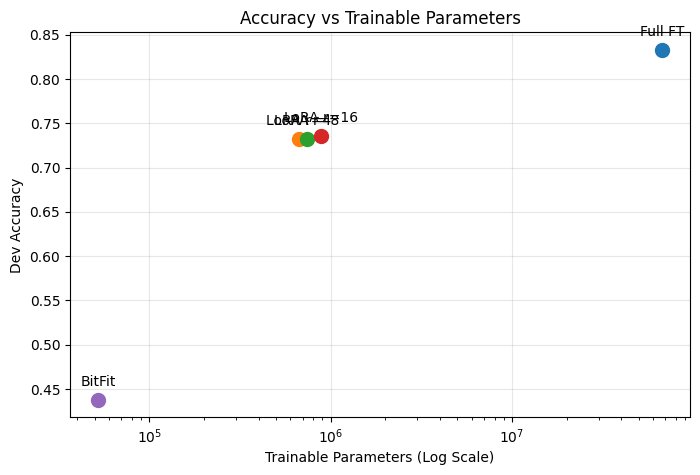

In [ ]:
df_peft = pd.DataFrame(peft_results)
print("PEFT Comparison Table:")
print(df_peft.to_string(index=False))

plt.figure(figsize=(8, 5))
for i, row in df_peft.iterrows():
    plt.scatter(row['params'], row['acc'], label=row['method'], s=100)
    plt.annotate(row['method'], (row['params'], row['acc']), textcoords="offset points", xytext=(0,10), ha='center')

plt.xscale('log')
plt.xlabel('Trainable Parameters (Log Scale)')
plt.ylabel('Dev Accuracy')
plt.title('Accuracy vs Trainable Parameters')
plt.grid(True, alpha=0.3)
plt.show()

### 3(c) Comparative Study

### 3(d) Possible Reasons Behind Observations

---
## Task 4: Cross-Dataset Generalisation

**Goal:** Evaluate zero-shot transfer to other NLI datasets.

### 4(a) Perform Task

In [ ]:
# Load saved baseline model
model_t4 = AutoModelForSequenceClassification.from_pretrained(
    str(MODEL_DIR / "task1_baseline"))
trainer_t4 = Trainer(model=model_t4,
    args=TrainingArguments(output_dir="./results/t4",
                           per_device_eval_batch_size=128,
                           report_to="none"),
    compute_metrics=compute_metrics)

eval_results = {}

# SNLI test
print("SNLI test...")
preds_s, labels_s = get_predictions(trainer_t4, test_tok)
eval_results["SNLI Test"] = accuracy_score(labels_s, preds_s)
print(f"  {eval_results['SNLI Test']:.4f}")

# MultiNLI
print("Loading MultiNLI...")
multinli = load_dataset("multi_nli")

for split_name, split_key in [("Matched", "validation_matched"),
                               ("Mismatched", "validation_mismatched")]:
    data = multinli[split_key]
    if MAX_TEST_EXAMPLES and len(data) > MAX_TEST_EXAMPLES:
        data = data.shuffle(seed=SEED).select(range(MAX_TEST_EXAMPLES))
    data = data.map(tokenize_fn, batched=True, num_proc=2)
    p, l = get_predictions(trainer_t4, data)
    eval_results[f"MultiNLI {split_name}"] = accuracy_score(l, p)
    print(f"  MultiNLI {split_name}: {eval_results[f'MultiNLI {split_name}']:.4f}")

# ANLI R1
print("Loading ANLI...")
anli = load_dataset("anli")
anli_r1 = anli["test_r1"].map(tokenize_fn, batched=True, num_proc=2)
preds_anli, labels_anli = get_predictions(trainer_t4, anli_r1)
eval_results["ANLI R1"] = accuracy_score(labels_anli, preds_anli)
print(f"  ANLI R1: {eval_results['ANLI R1']:.4f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

SNLI test...


  0.8280
Loading MultiNLI...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/214M [00:00<?, ?B/s]

...

Generating train_r3 split:   0%|          | 0/100459 [00:00<?, ? examples/s]

Generating dev_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating test_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/1000 [00:00<?, ? examples/s]

  ANLI R1: 0.3150


### 4(b) Analysis and Plots

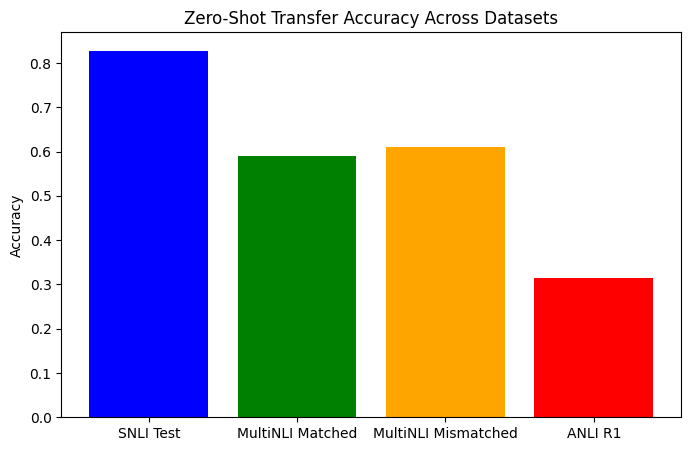

Confusion Matrix for ANLI R1:


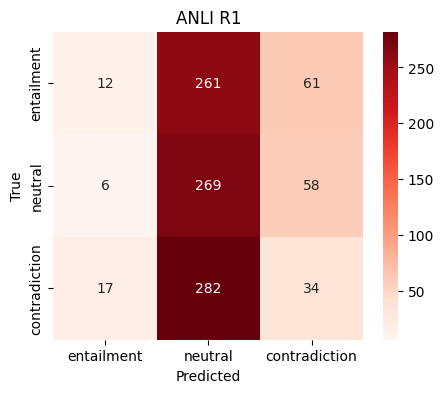

Confusion Matrix for MultiNLI Mismatched:


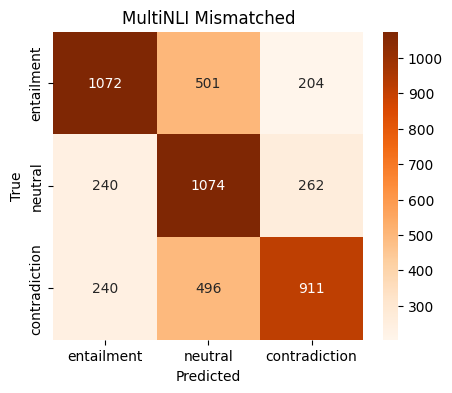


10 Misclassified ANLI R1 Examples:
Premise: Ernest Jones is a British jeweller and watchmaker. Established in 1949, its first store was opened in Oxford Street, London. Ernest Jones specialises in diamonds and watches, stocking brands such as Gucci and Emporio Armani. Ernest Jones is part of the Signet Jewelers group.
Hypothesis: The first Ernest Jones store was opened on the continent of Europe.
True Label: entailment
Pred Label: neutral
**************************************************
Premise: Old Trafford is a football stadium in Old Trafford, Greater Manchester, England, and the home of Manchester United. With a capacity of 75,643, it is the largest club football stadium in the United Kingdom, the second-largest football stadium, and the eleventh-largest in Europe. It is about 0.5 mi from Old Trafford Cricket Ground and the adjacent tram stop.
Hypothesis: There are only 10 larger football stadiums in Europe.
True Label: entailment
Pred Label: contradiction
**********************

In [ ]:
datasets = list(eval_results.keys())
accs = list(eval_results.values())

plt.figure(figsize=(8, 5))
plt.bar(datasets, accs, color=['blue', 'green', 'orange', 'red'])
plt.ylabel("Accuracy")
plt.title("Zero-Shot Transfer Accuracy Across Datasets")
plt.show()

print("Confusion Matrix for ANLI R1:")
cm_anli = confusion_matrix(labels_anli, preds_anli)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_anli, annot=True, fmt="d", cmap="Reds", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ANLI R1")
plt.show()

data_mismatched = multinli["validation_mismatched"]
if MAX_TEST_EXAMPLES and len(data_mismatched) > MAX_TEST_EXAMPLES:
    data_mismatched = data_mismatched.shuffle(seed=SEED).select(range(MAX_TEST_EXAMPLES))
data_mismatched = data_mismatched.map(tokenize_fn, batched=True, num_proc=2)
p_mm, l_mm = get_predictions(trainer_t4, data_mismatched)

print("Confusion Matrix for MultiNLI Mismatched:")
cm_mm = confusion_matrix(l_mm, p_mm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_mm, annot=True, fmt="d", cmap="Oranges", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MultiNLI Mismatched")
plt.show()

print("\n10 Misclassified ANLI R1 Examples:")
misclassified_idx = np.where(preds_anli != labels_anli)[0][:10]
for i in misclassified_idx:
    print(f"Premise: {anli_r1[int(i)]['premise']}")
    print(f"Hypothesis: {anli_r1[int(i)]['hypothesis']}")
    print(f"True Label: {LABEL_NAMES[labels_anli[i]]}")
    print(f"Pred Label: {LABEL_NAMES[preds_anli[i]]}")
    print("*" * 50)

### 4(c) Comparative Study

### 4(d) Possible Reasons Behind Observations

---
## Task 5: Data Efficiency Analysis

**Goal:** How much labelled data is needed for effective fine-tuning?

> Note: This task creates subsets relative to the **full** SNLI training set, not the subset used in earlier tasks.

### 5(a) Perform Task

In [18]:
fractions = [0.01, 0.10, 0.25, 0.50, 1.0]
results_t5 = []

for frac in fractions:
    set_seed()
    n = int(len(dataset["train"]) * frac)
    subset = dataset["train"].shuffle(seed=SEED).select(range(n))
    subset_tok = subset.map(tokenize_fn, batched=True, num_proc=2)

    model = get_fresh_model()
    args = make_training_args(f"./results/t5_frac_{frac}")

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=subset_tok,
        eval_dataset=val_tok,
        compute_metrics=compute_metrics
    )

    print(f"Training on {frac*100}% data ({n} examples)...")
    trainer.train()
    acc = trainer.evaluate()["eval_accuracy"]
    results_t5.append({"Fraction": frac, "Accuracy": acc})
    cleanup()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training on 1.0% data (5493 examples)...


Epoch,Training Loss,Validation Loss,Accuracy
1,1.045323,0.804876,0.658400


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Map (num_proc=2):   0%|          | 0/549367 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training on 100.0% data (549367 examples)...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.384980,0.318478,0.882400


### 5(b) Analysis and Plots

Data Efficiency Results:
 Fraction  Accuracy  StdDev
     0.01    0.6584     0.0
     0.10    0.8144     0.0
     0.25    0.8420     0.0
     0.50    0.8656     0.0
     1.00    0.8824     0.0


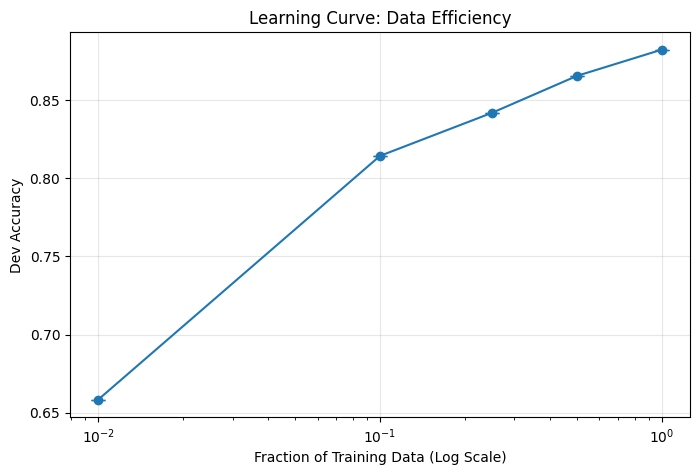

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df_t5 = pd.DataFrame(results_t5)
df_t5["StdDev"] = 0.0

print("Data Efficiency Results:")
print(df_t5.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.errorbar(df_t5['Fraction'], df_t5['Accuracy'], yerr=df_t5['StdDev'], fmt='-o', capsize=5)
plt.xscale('log')
plt.xlabel('Fraction of Training Data (Log Scale)')
plt.ylabel('Dev Accuracy')
plt.title('Learning Curve: Data Efficiency')
plt.grid(True, alpha=0.3)
plt.show()

### 5(c) Comparative Study

### 5(d) Possible Reasons Behind Observations